#### AI Disclosure :

I worked on this project with some support from AI tools such as ChatGPT to assist me in making the task smoother and to enhance my learning along the way. I used AI tools mainly to get guidance on how to code, what the appropriate syntax was, and how to approach different options for building models and workflows. I also used AI tools to help me understand concepts I learned from the research paper and to assist me in crafting some parts of the project.



### Reproducibility in Data Science: A Data Ethics Project

In [4]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.api import VAR


#### LOAD DATA

In [8]:
file_path = ("data/2026-02-MD (Dataset Used in the Paper).csv")
raw_df = pd.read_csv(file_path)

print("Original shape:", raw_df.shape)


Original shape: (806, 127)


In [10]:
print("\nFirst 5 rows:")
print(raw_df.head())



First 5 rows:
      sasdate       RPI  W875RX1  DPCERA3M086SBEA    CMRMTSPLx      RETAILx  \
0  Transform:     5.000      5.0            5.000       5.0000      5.00000   
1    1/1/1959  2583.560   2426.0           15.188  276676.8154  17689.23968   
2    2/1/1959  2593.596   2434.8           15.346  278713.9773  17819.01912   
3    3/1/1959  2610.396   2452.7           15.491  277775.2539  17967.91336   
4    4/1/1959  2627.446   2470.0           15.435  283362.7075  17978.97983   

    INDPRO  IPFPNSS  IPFINAL  IPCONGD  ...  DNDGRG3M086SBEA  DSERRG3M086SBEA  \
0   5.0000   5.0000   5.0000   5.0000  ...            6.000            6.000   
1  21.9998  23.6312  22.5507  32.1377  ...           18.294           10.152   
2  22.4306  23.9501  22.7461  32.3734  ...           18.302           10.167   
3  22.7538  24.0951  22.8577  32.3734  ...           18.289           10.185   
4  23.2384  24.4431  23.1926  32.8841  ...           18.300           10.221   

   CES0600000008  CES20000000

In [11]:
print("\nColumns:")
print(raw_df.columns.tolist())


Columns:
['sasdate', 'RPI', 'W875RX1', 'DPCERA3M086SBEA', 'CMRMTSPLx', 'RETAILx', 'INDPRO', 'IPFPNSS', 'IPFINAL', 'IPCONGD', 'IPDCONGD', 'IPNCONGD', 'IPBUSEQ', 'IPMAT', 'IPDMAT', 'IPNMAT', 'IPMANSICS', 'IPB51222S', 'IPFUELS', 'CUMFNS', 'HWI', 'HWIURATIO', 'CLF16OV', 'CE16OV', 'UNRATE', 'UEMPMEAN', 'UEMPLT5', 'UEMP5TO14', 'UEMP15OV', 'UEMP15T26', 'UEMP27OV', 'CLAIMSx', 'PAYEMS', 'USGOOD', 'CES1021000001', 'USCONS', 'MANEMP', 'DMANEMP', 'NDMANEMP', 'SRVPRD', 'USTPU', 'USWTRADE', 'USTRADE', 'USFIRE', 'USGOVT', 'CES0600000007', 'AWOTMAN', 'AWHMAN', 'HOUST', 'HOUSTNE', 'HOUSTMW', 'HOUSTS', 'HOUSTW', 'PERMIT', 'PERMITNE', 'PERMITMW', 'PERMITS', 'PERMITW', 'ACOGNO', 'AMDMNOx', 'ANDENOx', 'AMDMUOx', 'BUSINVx', 'ISRATIOx', 'M1SL', 'M2SL', 'M2REAL', 'BOGMBASE', 'TOTRESNS', 'NONBORRES', 'BUSLOANS', 'REALLN', 'NONREVSL', 'CONSPI', 'S&P 500', 'S&P div yield', 'S&P PE ratio', 'FEDFUNDS', 'CP3Mx', 'TB3MS', 'TB6MS', 'GS1', 'GS5', 'GS10', 'AAA', 'BAA', 'COMPAPFFx', 'TB3SMFFM', 'TB6SMFFM', 'T1YFFM', 'T

#### CLEAN DATA

In [12]:
df = raw_df.iloc[1:].copy()
df = df.rename(columns={"sasdate": "date"})
df["date"] = pd.to_datetime(df["date"], errors="coerce")

for col in df.columns:
    if col != "date":
        df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.set_index("date").sort_index()

print("\nShape after removing first row:", df.shape)



Shape after removing first row: (805, 126)


#### CHECK MISSING VALUES

In [13]:
missing_counts = df.isna().sum()
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)

print("\nTop columns with missing values:")
print(missing_counts.head(20))

# Drop columns with more than 20% missing values
threshold = int(0.2 * len(df))
df = df.dropna(axis=1, thresh=len(df) - threshold)

# Fill remaining missing values
df = df.interpolate(method="linear")
df = df.ffill().bfill()

print("\nRemaining missing values:", df.isna().sum().sum())
print("Cleaned shape:", df.shape)



Top columns with missing values:
ACOGNO             398
TWEXAFEGSMTHx      168
UMCSENTx           154
ANDENOx            110
VIXCLSx             42
PERMIT              13
PERMITW             13
PERMITS             13
PERMITMW            13
PERMITNE            13
S&P PE ratio         3
ISRATIOx             2
BUSINVx              2
CMRMTSPLx            2
HWIURATIO            2
CUSR0000SA0L5        1
DNDGRG3M086SBEA      1
CP3Mx                1
COMPAPFFx            1
DTCTHFNM             1
dtype: int64

Remaining missing values: 0
Cleaned shape: (805, 124)


#### SCALE DATA

In [14]:
scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df),
    index=df.index,
    columns=df.columns
)

print("\nScaled data preview:")
print(df_scaled.head())



Scaled data preview:
                 RPI   W875RX1  DPCERA3M086SBEA  CMRMTSPLx   RETAILx  \
date                                                                   
1959-01-01 -1.373714 -1.421085        -1.347337  -1.425545 -1.069197   
1959-02-01 -1.371792 -1.418954        -1.342340  -1.420360 -1.068533   
1959-03-01 -1.368574 -1.414620        -1.337755  -1.422750 -1.067772   
1959-04-01 -1.365309 -1.410431        -1.339526  -1.408528 -1.067715   
1959-05-01 -1.362383 -1.406460        -1.333612  -1.403578 -1.066995   

              INDPRO   IPFPNSS   IPFINAL   IPCONGD  IPDCONGD  ...  \
date                                                          ...   
1959-01-01 -1.721630 -1.818867 -1.799052 -2.078649 -1.717672  ...   
1959-02-01 -1.705578 -1.807023 -1.791868 -2.068439 -1.714024  ...   
1959-03-01 -1.693535 -1.801638 -1.787765 -2.068439 -1.700347  ...   
1959-04-01 -1.675479 -1.788714 -1.775451 -2.046317 -1.695788  ...   
1959-05-01 -1.662434 -1.781178 -1.767241 -2.039507 -1.68119

#### TRAIN / TEST SPLIT

In [15]:
train_size = int(len(df_scaled) * 0.8)
train = df_scaled.iloc[:train_size]
test = df_scaled.iloc[train_size:]

print("\nTrain shape:", train.shape)
print("Test shape:", test.shape)

TARGET = "INDPRO"



Train shape: (644, 124)
Test shape: (161, 124)


#### METRICS FUNCTION

In [17]:
def get_metrics(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {
        "Model": model_name,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    }


results_list = []


#### BASELINE AR MODEL

In [18]:
ar_model = AutoReg(train[TARGET], lags=1, old_names=False).fit()
ar_pred = ar_model.predict(start=len(train), end=len(train) + len(test) - 1)
ar_pred = pd.Series(ar_pred, index=test.index)

ar_result_df = pd.DataFrame({
    "Actual": test[TARGET],
    "Predicted_AR": ar_pred
})

print("\nAR Model Results:")
print(ar_result_df.head())

results_list.append(get_metrics(test[TARGET], ar_pred, "AR"))


AR Model Results:
              Actual  Predicted_AR
date                              
2012-09-01  1.087129      1.093771
2012-10-01  1.099734      1.097747
2012-11-01  1.113088      1.101723
2012-12-01  1.121748      1.105697
2013-01-01  1.122646      1.109671


#### VAR MODEL

In [21]:
selected_cols = ["INDPRO", "CPIAUCSL", "UNRATE", "FEDFUNDS", "PAYEMS"]
selected_cols = [col for col in selected_cols if col in df_scaled.columns]

train_var = train[selected_cols]
test_var = test[selected_cols]

var_model = VAR(train_var)
lag_results = var_model.select_order(maxlags=10)
print("\nVAR Lag Selection:")
print(lag_results.summary())

var_fitted = var_model.fit(3)
print("\nVAR Summary:")
print(var_fitted.summary())

lag_order = var_fitted.k_ar
forecast_input = train_var.values[-lag_order:]
var_forecast = var_fitted.forecast(y=forecast_input, steps=len(test_var))
var_forecast_df = pd.DataFrame(var_forecast, index=test_var.index, columns=test_var.columns)

print("\nVAR Predictions:")
print(var_forecast_df.head())

results_list.append(get_metrics(test_var[TARGET], var_forecast_df[TARGET], "VAR"))


VAR Lag Selection:
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -9.199      -9.164   0.0001012      -9.185
1       -38.16      -37.95   2.676e-17      -38.08
2       -39.14      -38.75   1.005e-17      -38.99
3       -39.44     -38.88*   7.438e-18     -39.22*
4       -39.46      -38.73   7.266e-18      -39.18
5       -39.47      -38.55   7.238e-18      -39.11
6      -39.51*      -38.42  6.965e-18*      -39.08
7       -39.48      -38.22   7.124e-18      -38.99
8       -39.47      -38.03   7.204e-18      -38.91
9       -39.48      -37.87   7.142e-18      -38.85
10      -39.46      -37.67   7.316e-18      -38.76
--------------------------------------------------

VAR Summary:
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 30, Mar, 2026
Time:                     23:55:28
--------------------------

#### FACTOR MODEL USING PCA + LINEAR REGRESSION

In [23]:
n_factors = 3
pca = PCA(n_components=n_factors)

train_factors = pca.fit_transform(train)
test_factors = pca.transform(test)

factor_cols = [f"Factor_{i+1}" for i in range(n_factors)]
train_factor_df = pd.DataFrame(train_factors, index=train.index, columns=factor_cols)
test_factor_df = pd.DataFrame(test_factors, index=test.index, columns=factor_cols)

train_factor_df["TARGET_LAG1"] = train[TARGET].shift(1)
train_factor_df["TARGET"] = train[TARGET]
train_factor_df = train_factor_df.dropna()

test_factor_df["TARGET_LAG1"] = pd.concat([train[TARGET].iloc[-1:], test[TARGET].iloc[:-1]]).values
test_factor_df["TARGET"] = test[TARGET].values

X_train_factor = train_factor_df.drop(columns=["TARGET"])
y_train_factor = train_factor_df["TARGET"]

X_test_factor = test_factor_df.drop(columns=["TARGET"])
y_test_factor = test_factor_df["TARGET"]

factor_model = LinearRegression()
factor_model.fit(X_train_factor, y_train_factor)
factor_pred = factor_model.predict(X_test_factor)

print("\nFactor Model Predictions:")
print(factor_pred[:5])

results_list.append(get_metrics(y_test_factor, factor_pred, "Factor Model"))


Factor Model Predictions:
[1.08731482 1.0852944  1.09723874 1.11118988 1.11916778]


#### NNAR-STYLE MODEL USING MLP

In [25]:
def make_lagged_data(series, lags=12):
    lagged = pd.DataFrame({"y": series})
    for i in range(1, lags + 1):
        lagged[f"lag_{i}"] = lagged["y"].shift(i)
    return lagged.dropna()

lagged_data = make_lagged_data(df_scaled[TARGET], lags=12)

split_index = int(len(lagged_data) * 0.8)
lagged_train = lagged_data.iloc[:split_index]
lagged_test = lagged_data.iloc[split_index:]

X_train_nnar = lagged_train.drop(columns=["y"])
y_train_nnar = lagged_train["y"]

X_test_nnar = lagged_test.drop(columns=["y"])
y_test_nnar = lagged_test["y"]

nnar_model = MLPRegressor(hidden_layer_sizes=(20,), max_iter=1000, random_state=42)
nnar_model.fit(X_train_nnar, y_train_nnar)
nnar_pred = nnar_model.predict(X_test_nnar)

print("\nNNAR Predictions:")
print(nnar_pred[:5])

results_list.append(get_metrics(y_test_nnar, nnar_pred, "NNAR (MLP)"))


NNAR Predictions:
[0.98971351 0.98607486 0.98629024 0.98348147 0.98019773]


#### TREE-BASED MODEL USING RANDOM FOREST

In [27]:
rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train_factor, y_train_factor)
rf_pred = rf_model.predict(X_test_factor)

print("\nRandom Forest Predictions:")
print(rf_pred[:5])

results_list.append(get_metrics(y_test_factor, rf_pred, "Random Forest"))



Random Forest Predictions:
[1.0976707  1.09221869 1.09755702 1.04503079 1.07636587]


#### MODEL COMPARISON TABLE

In [29]:
metrics_df = pd.DataFrame(results_list)
print("\nModel Comparison:")
print(metrics_df.sort_values("RMSE"))



Model Comparison:
           Model      RMSE       MAE        R2
4   Factor Model  0.048897  0.023474  0.729494
2   Factor Model  0.048897  0.023474  0.729494
6  Random Forest  0.054659  0.030365  0.661987
1            VAR  0.170463  0.131838 -2.287544
3            VAR  0.170463  0.131838 -2.287544
5     NNAR (MLP)  0.204286  0.197752 -3.734580
0             AR  0.291989  0.233291 -8.645875


### ROLLING FORECAST COMPARISON (AR vs VAR)

In [31]:
roll_data = df_scaled[selected_cols].dropna().copy()

var_preds = []
ar_preds = []
actual_vals = []
roll_dates = []

for i in range(200, len(roll_data) - 1):
    train_roll = roll_data.iloc[:i]
    test_point = roll_data.iloc[i:i+1]

    try:
        # VAR
        var_roll_model = VAR(train_roll)
        var_roll_res = var_roll_model.fit(3)
        var_input = train_roll.values[-3:]
        var_forecast_1 = var_roll_res.forecast(var_input, steps=1)[0][0]

        # AR
        ar_roll_model = AutoReg(train_roll[TARGET], lags=1, old_names=False).fit()
        ar_forecast_1 = ar_roll_model.predict(start=len(train_roll), end=len(train_roll)).iloc[0]

        var_preds.append(var_forecast_1)
        ar_preds.append(ar_forecast_1)
        actual_vals.append(test_point[TARGET].values[0])
        roll_dates.append(test_point.index[0])

    except:
        continue

actual_vals = np.array(actual_vals)
var_preds = np.array(var_preds)
ar_preds = np.array(ar_preds)

var_rmsfe = np.sqrt(np.mean((actual_vals - var_preds) ** 2))
ar_rmsfe = np.sqrt(np.mean((actual_vals - ar_preds) ** 2))
rmsfe_ratio = var_rmsfe / ar_rmsfe

print("\nRolling Forecast Results:")
print("VAR RMSFE:", var_rmsfe)
print("AR RMSFE:", ar_rmsfe)
print("VAR / AR RMSFE Ratio:", rmsfe_ratio)



Rolling Forecast Results:
VAR RMSFE: 0.05660897399282783
AR RMSFE: 0.030594536545237562
VAR / AR RMSFE Ratio: 1.8502968302567653


### PLOT ACTUAL VS FORECAST

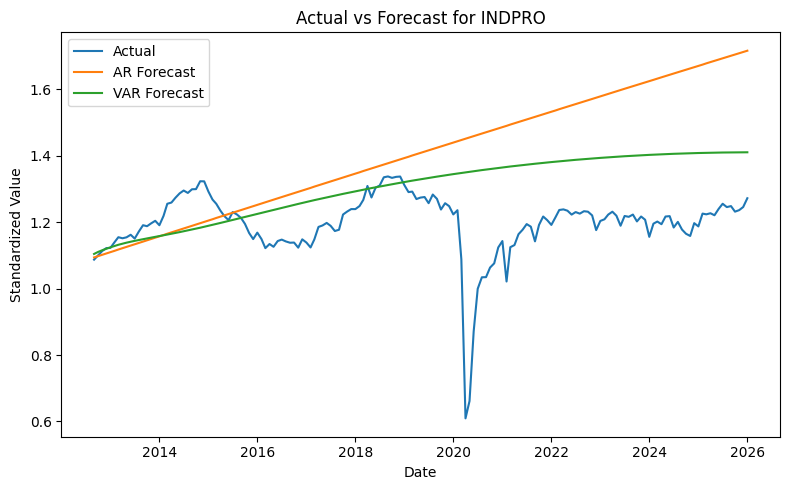

In [34]:
plt.figure(figsize=(8, 5))
plt.plot(test.index, test[TARGET], label="Actual")
plt.plot(test.index, ar_pred, label="AR Forecast")
plt.plot(test_var.index, var_forecast_df[TARGET], label="VAR Forecast")
plt.title("Actual vs Forecast for INDPRO")
plt.xlabel("Date")
plt.ylabel("Standardized Value")
plt.legend()
plt.tight_layout()
plt.show()

###  PLOT ROLLING FORECAST COMPARISON

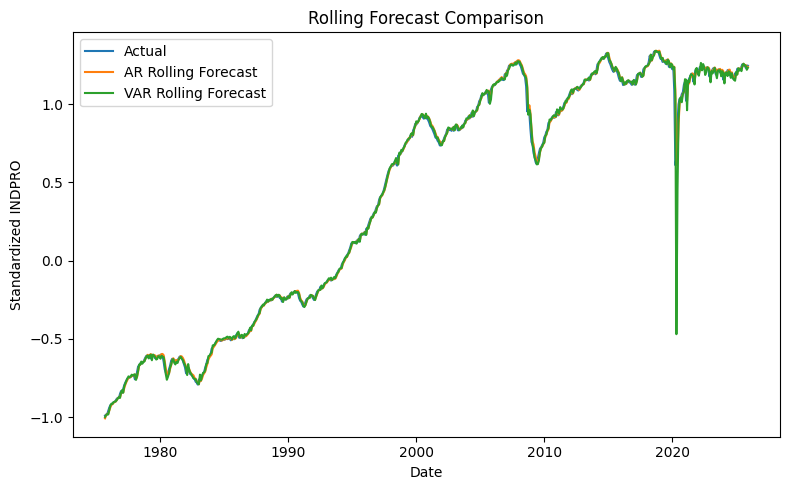

In [36]:
plt.figure(figsize=(8, 5))
plt.plot(roll_dates, actual_vals, label="Actual")
plt.plot(roll_dates, ar_preds, label="AR Rolling Forecast")
plt.plot(roll_dates, var_preds, label="VAR Rolling Forecast")
plt.title("Rolling Forecast Comparison")
plt.xlabel("Date")
plt.ylabel("Standardized INDPRO")
plt.legend()
plt.tight_layout()
plt.show()

### RELATIVE RMSFE TABLE FOR MULTIPLE TARGETS

In [38]:
candidate_targets = [
    "INDPRO", "UNRATE", "CPIAUCSL", "FEDFUNDS", "PAYEMS",
    "HOUST", "PERMIT", "TB3MS", "GS10", "UMCSENTx"
]

candidate_targets = [c for c in candidate_targets if c in df_scaled.columns]

relative_scores = []

for target in candidate_targets:
    one_df = df_scaled[[target]].dropna().copy()

    if len(one_df) < 250:
        continue

    split = int(len(one_df) * 0.8)
    train_t = one_df.iloc[:split]
    test_t = one_df.iloc[split:]

    # AR benchmark
    ar_t = AutoReg(train_t[target], lags=1, old_names=False).fit()
    ar_pred_t = ar_t.predict(start=len(train_t), end=len(train_t) + len(test_t) - 1)
    ar_rmse_t = np.sqrt(mean_squared_error(test_t[target], ar_pred_t))

    # If target is in selected columns, compare with VAR
    if target in selected_cols:
        mv_df = df_scaled[selected_cols].dropna().copy()
        split_mv = int(len(mv_df) * 0.8)
        tr = mv_df.iloc[:split_mv]
        te = mv_df.iloc[split_mv:]

        mv_model = VAR(tr)
        mv_res = mv_model.fit(3)
        mv_input = tr.values[-3:]
        mv_fc = mv_res.forecast(mv_input, steps=len(te))
        mv_fc_df = pd.DataFrame(mv_fc, columns=tr.columns, index=te.index)

        mv_rmse_t = np.sqrt(mean_squared_error(te[target], mv_fc_df[target]))
        rel_score = mv_rmse_t / ar_rmse_t
        relative_scores.append([target, "VAR", rel_score])

    relative_scores.append([target, "AR", 1.0])

relative_df = pd.DataFrame(relative_scores, columns=["Target", "Model", "Relative_RMSFE"])

print("\nRelative RMSFE Table:")
print(relative_df)


Relative RMSFE Table:
      Target Model  Relative_RMSFE
0     INDPRO   VAR        0.583801
1     INDPRO    AR        1.000000
2     UNRATE   VAR        0.790408
3     UNRATE    AR        1.000000
4   CPIAUCSL   VAR        2.996207
5   CPIAUCSL    AR        1.000000
6   FEDFUNDS   VAR        5.069993
7   FEDFUNDS    AR        1.000000
8     PAYEMS   VAR        2.441591
9     PAYEMS    AR        1.000000
10     HOUST    AR        1.000000
11    PERMIT    AR        1.000000
12     TB3MS    AR        1.000000
13      GS10    AR        1.000000
14  UMCSENTx    AR        1.000000


###  BOXPLOT OF RELATIVE RMSFE

<Figure size 800x600 with 0 Axes>

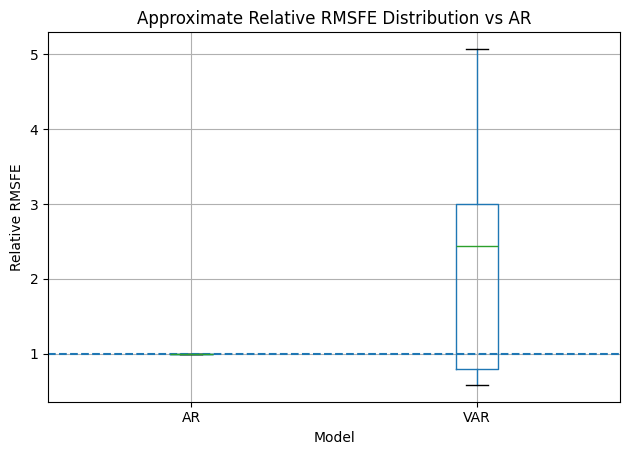

In [40]:
if not relative_df.empty:
    plt.figure(figsize=(8, 6))
    relative_df.boxplot(column="Relative_RMSFE", by="Model")
    plt.axhline(1.0, linestyle="--")
    plt.title("Approximate Relative RMSFE Distribution vs AR")
    plt.suptitle("")
    plt.ylabel("Relative RMSFE")
    plt.tight_layout()
    plt.show()

### Summary

This project focuses on analyzing a large macroeconomic dataset and building different models to forecast industrial production (INDPRO). The data was first cleaned by removing the transformation row, converting values to proper formats, handling missing values, and standardizing all variables so that they are on the same scale. After preparing the data, it was split into training and testing sets to evaluate model performance properly.

Several forecasting approaches were implemented. A basic autoregressive (AR) model was used as a baseline to understand how well past values alone can predict future values. Then, a VAR model was built to capture relationships between multiple economic indicators like inflation, unemployment, and interest rates. Along with these traditional time-series models, machine learning methods were also applied. A factor model using PCA reduced the dataset into a few key components, while a neural network (MLP) and a random forest model were used to capture more complex patterns.

To compare all models, evaluation metrics like RMSE, MAE, and R² were calculated. In addition, a rolling forecast approach was used to simulate real-world predictions over time, which gave a better understanding of how stable and reliable each model is. Finally, the performance of different models across multiple economic variables was compared using relative RMSFE, with AR used as the baseline.

Overall, this work shows how both statistical and machine learning models can be applied to economic forecasting, and it highlights that while simpler models are useful as benchmarks, combining multiple variables or using advanced methods can sometimes improve prediction accuracy depending on the data.